# 05 - Evaluación: Evaluación Comparativa de Modelos

**Fase del Pipeline DSR: Evaluación y Recomendación de Despliegue**

Este notebook realiza la evaluación comparativa completa de los 4 modelos
de detección de anomalías no supervisados usando:
- **Métricas intrínsecas:** Silhouette, Davies-Bouldin, Calinski-Harabasz (calidad del cluster)
- **Métricas extrínsecas:** Accuracy, Sensibilidad, Especificidad, F1, AUC-ROC (vs verdad de campo AAMI)
- **Métricas de eficiencia:** Tiempo de entrenamiento, uso máximo de memoria

El `ModelComparator` ejecuta todos los modelos y produce una tabla de comparación unificada.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.seeding import set_global_seed
from ecg_anomaly.cache import get_or_build_preprocessed
from ecg_anomaly.data.splitting import make_interpatient_split, make_normal_fit_split
from ecg_anomaly.features.manual import ManualFeatureExtractor
from ecg_anomaly.models.factory import DetectorFactory
from ecg_anomaly.evaluation.comparator import ModelComparator
from ecg_anomaly.evaluation.extrinsic import evaluate_extrinsic
from ecg_anomaly.evaluation.intrinsic import evaluate_intrinsic
from ecg_anomaly.visualization.reports import plot_metrics_comparison, plot_confusion_matrices
from ecg_anomaly.visualization.clusters import plot_pca_scatter
from ecg_anomaly.visualization.labels import LABELS_ES

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()
set_global_seed(config.random_seed)

## 1. Preparar Datos (Pipeline Completo)

In [2]:
preprocessed = get_or_build_preprocessed(config)

# Split inter-paciente DS1/DS2 (de Chazal et al., 2004): el scaler/PCA/
# autoencoder se ajustan SOLO con normales de registros DS1 (fit_idx);
# las metricas se miden sobre TODO DS2 (eval_idx), pacientes que el
# modelo nunca vio. Cierra la fuga de clase Y la de paciente. Vease la
# nota metodologica mas abajo.
record_ids = preprocessed.metadata["record_ids"]
fit_idx, eval_idx = make_interpatient_split(preprocessed, record_ids)

# Split intra-paciente (por latido), conservado SOLO para cuantificar
# el sesgo de ese paradigma frente al inter-paciente (Seccion 10).
fit_idx_intra, eval_idx_intra = make_normal_fit_split(preprocessed, seed=config.random_seed)

# Path B: Manual features con ventanas temporales (22 features)
extractor = ManualFeatureExtractor()
X_clustering_raw = extractor.extract(
    preprocessed.segments,
    preprocessed.r_peaks_flat,
    config.sampling_rate,
    preprocessed.record_indices,
)

# IMPORTANTE: K-Means/DBSCAN/HDBSCAN son sensibles a la escala. Las 22
# features van de ~1 (amplitudes) a ~800 (RR en ms); sin estandarizar, la
# distancia euclidiana la domina el intervalo RR y las demas 20 features
# casi no influyen. Ajustamos el scaler SOLO con normales (misma politica
# anti-fuga que el autoencoder) y lo aplicamos a todo el dataset.
clust_scaler = StandardScaler()
clust_scaler.fit(X_clustering_raw[fit_idx])
X_clustering = clust_scaler.transform(X_clustering_raw)

# El scaler del autoencoder se ajusta SOLO con normales (fit_idx) y se
# aplica a todo el dataset: el autoencoder debe aprender como es un
# latido normal sin haber "visto" anomalias ni normales de evaluacion.
ae_scaler = StandardScaler()
ae_scaler.fit(preprocessed.segments[fit_idx])
X_autoencoder = ae_scaler.transform(preprocessed.segments)
true_labels = preprocessed.labels

# PCA 2D for visualization only
pca_vis = PCA(n_components=2, random_state=42)
X_pca_vis = pca_vis.fit_transform(X_clustering)

print(f"Dataset: {preprocessed.metadata['n_beats']:,} beats from {preprocessed.metadata['n_records']} records")
print(f"Clustering features (Manual 22d): {X_clustering.shape}")
print(f"Autoencoder features (raw): {X_autoencoder.shape}")
print(f"Fit inter-paciente (DS1, solo normal): {len(fit_idx):,} | Eval (DS2 completo): {len(eval_idx):,} ({len(eval_idx)/preprocessed.metadata['n_beats']*100:.1f}% del dataset)")
print(f"Class distribution: Normal={int(np.sum(true_labels==0)):,}, Anomalous={int(np.sum(true_labels==1)):,}")

[cache] Cargando preprocesamiento desde pp_lc0.5_hc40.0_ord4_b90_a110.joblib


16:00:19 [ecg_anomaly.features.manual] INFO: Features manuales: 100705 latidos x 22 features


Dataset: 100,705 beats from 44 records
Clustering features (Manual 22d): (100705, 22)
Autoencoder features (raw): (100705, 200)
Fit inter-paciente (DS1, solo normal): 45,854 | Eval (DS2 completo): 49,697 (49.3% del dataset)
Class distribution: Normal=90,099, Anomalous=10,606


**Por que un split inter-paciente (DS1/DS2):** ajustar el `StandardScaler` y el autoencoder sobre latidos normales del MISMO paciente que luego se evalua no es solo fuga de clase -- es tambien fuga de paciente. La morfologia del ECG es fuertemente individual [de Chazal et al., 2004]: un latido normal del paciente 100 puede parecerse mas a un latido anomalo del paciente 233 que a un latido normal de otro paciente. Por eso el split principal de este notebook agrupa por REGISTRO, no por latido: `fit_idx` son solo normales de los 22 registros DS1, y `eval_idx` son TODOS los latidos (normales y anomalos) de los 22 registros DS2, pacientes que el modelo nunca vio durante el ajuste. Esto responde la pregunta clinicamente relevante -- "?funciona esto para un paciente que llega manana?" -- en vez de "?memorizo el modelo a estos pacientes?". La Seccion 10 cuantifica cuanto cambia el resultado frente al split intra-paciente (por latido) que se usaba antes.

## 1b. ¿Por qué métricas intrínsecas y extrínsecas?

### Métricas Intrínsecas (No supervisadas)
Silhouette, Davies-Bouldin y Calinski-Harabasz evalúan la **calidad geométrica** de los clusters sin usar etiquetas. Esto refleja el escenario no supervisado real donde no hay ground truth disponible. Un Silhouette alto y Davies-Bouldin bajo indican clusters bien separados, condición necesaria para una detección de anomalías confiable.

### Métricas Extrínsecas (Evaluación supervisada)
Accuracy, Sensitivity, Specificity, F1 y AUC-ROC comparan las predicciones contra el estándar de oro clínico AAMI. Esto permite:
1. **Cuantificar el rendimiento clínico** de cada método
2. **Comparar contra la literatura publicada**
3. **Identificar tipos de error** (FP vs FN) que comete cada método

### ¿Por qué ambas?
Las métricas intrínsecas indican si el modelo encuentra **estructura geométrica significativa**. Las extrínsecas indican si esa estructura **corresponde a patología real**. Un modelo puede tener excelente geometría (Silhouette alto) pero mal alineamiento clínico (F1 bajo), o viceversa. Ambas perspectivas son necesarias para una evaluación completa.

**Nota clínica:** En el screening ECG médico, **los falsos negativos (anomalías no detectadas) son más críticos** que los falsos positivos (falsas alarmas). Un modelo que omite anomalías es clínicamente inútil sin importar su Accuracy. Por lo tanto, **Sensitivity** es una métrica clave a monitorear.

## 1c. Asignación heurística cluster-a-clase

Los cuatro métodos usan **reglas heurísticas** para mapear salidas no supervisadas a etiquetas binarias normal/anómalo:

| Método | Regla Heurística |
|--------|------------------|
| K-Means | Distancia normalizada al centroide > valla de Tukey (Q3 + 1.5*IQR) sobre los scores (sin mirar el ground truth) = anómalo |
| DBSCAN | Puntos de ruido (etiqueta = -1) = anómalo |
| HDBSCAN | Puntos de ruido (etiqueta = -1) = anómalo |
| Autoencoder | Error de reconstrucción ≥ percentil (1 - normal_fpr) de los errores del fit set (100% normal) = anómalo |

**Limitación:** Estos supuestos deben validarse clínicamente. K-Means, en particular, asume implícitamente clusters esféricos de tamaño similar (por eso su heurística de distancia al centroide funciona mejor con esa geometría) -- algo que no siempre se cumple en el espacio de features de ECG. El diagnóstico de la Sección 2b reporta el rendimiento real de esta heurística, ya con los datos estandarizados.\n\nPara el detalle completo de cómo se construyó cada una de las 22 features y su justificación, ver `04_clustering.ipynb` (Sección 6, nota sobre asignación heurística).

**Qué hace el diagnóstico que sigue (Sección 2b):**

En vez de comparar dos asignaciones A/B basadas en el *tamaño* de los clusters
internos de K-Means (un enfoque que resultó engañoso: uno de los 10 clusters
puede tener 1 solo punto sin que eso signifique que el modelo "colapsó"),
diagnosticamos directamente sobre `kmeans.anomaly_labels_` -- la misma salida
(distancia normalizada + umbral por valla de Tukey) que evalúa el comparador y que
alimenta la tabla de resultados, medida sobre el mismo conjunto held-out
(`eval_idx`, registros DS2). Los tamaños de los clusters internos se muestran únicamente como
información estructural, nunca como la predicción.

> **Nota metodológica:** este diagnóstico es honesto por construcción: usa la
> misma regla de decisión y el mismo conjunto de evaluación (`eval_idx`) que ya
> se reporta en la tabla de comparación, así que sus métricas son, por
> definición, consistentes con esa tabla -- no hay dos números distintos para
> "el mismo" K-Means.

## 1d. Etiquetas AAMI: Solo para evaluación

**Importante:** Las anotaciones AAMI (normal vs anómalo) se usan **EXCLUSIVAMENTE para evaluación**, nunca durante el entrenamiento del modelo. Esto asegura:

- La comparación es **justa** entre los 4 métodos
- Los resultados reflejan un **escenario real de despliegue no supervisado**
- Cualquier alineación con etiquetas clínicas es **descubierta**, no impuesta

La naturaleza no supervisada de los 4 métodos se preserva en todo el pipeline.

## 2. Ejecutar Evaluación Comparativa

El `ModelComparator` entrena cada modelo, mide la eficiencia y calcula
todas las métricas intrínsecas y extrínsecas en una sola pasada.

In [3]:
# Seccion 2: ejecutar la evaluacion comparativa completa (los 4 modelos)
# eval_idx se aplica a TODOS los modelos: las metricas se miden solo
# sobre DS2 (held-out inter-paciente), nunca sobre datos de entrenamiento.
comparator = ModelComparator(config)
results_df = comparator.run_all(
    X_clustering, X_autoencoder, true_labels,
    autoencoder_fit_idx=fit_idx, eval_idx=eval_idx,
)
print(f"Modelos evaluados: {len(comparator.results)}")
print(f"Metricas medidas sobre {len(eval_idx):,} latidos held-out "
      f"({len(eval_idx)/len(true_labels)*100:.1f}% del dataset)")

16:00:19 [ecg_anomaly.evaluation.comparator] INFO: Evaluando kmeans...
16:03:02 [ecg_anomaly.evaluation.comparator] INFO: kmeans completado: F1=0.344, Silhouette=0.250, Tiempo=5.91s
16:03:02 [ecg_anomaly.evaluation.comparator] INFO: Evaluando dbscan...
16:03:18 [ecg_anomaly.models.dbscan] INFO: DBSCAN eps auto-optimizado (p90): 2.1450
16:05:34 [ecg_anomaly.evaluation.comparator] INFO: dbscan completado: F1=0.199, Silhouette=-0.022, Tiempo=28.64s
16:05:34 [ecg_anomaly.evaluation.comparator] INFO: Evaluando hdbscan...
16:10:10 [ecg_anomaly.models.hdbscan_model] INFO: HDBSCAN: 233 clusters, 55804 ruido (55.4%)
16:10:38 [ecg_anomaly.evaluation.comparator] INFO: hdbscan completado: F1=0.231, Silhouette=0.258, Tiempo=276.14s
16:10:38 [ecg_anomaly.evaluation.comparator] INFO: Evaluando autoencoder...
16:10:39 [tensorflow] WARNING: TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the Ten

Modelos evaluados: 4
Metricas medidas sobre 49,697 latidos held-out (49.3% del dataset)


### 2b. Diagnóstico honesto de K-Means

K-Means marca anomalías por percentil de distancia al centroide (top ~10.5%),
la misma regla que ya evaluó el comparador arriba. Diagnosticamos sobre esa
salida -- no sobre los tamaños de los 10 clusters internos -- para que el
número reportado aquí sea el mismo que aparece en la tabla de resultados.

In [4]:
# Reutilizamos el K-Means ya entrenado por el comparador en vez de
# reajustarlo aqui: evita entrenar K-Means dos veces (con el riesgo de
# obtener una particion ligeramente distinta si el random_state no
# coincide exactamente en ambos lugares).
kmeans_idx = config.models.index("kmeans")
kmeans = comparator.detectors[kmeans_idx]  # mismo objeto, mismas labels_

# K-Means marca anomalias por DISTANCIA NORMALIZADA al centroide, con
# umbral por valla de Tukey (la misma regla que evalua el comparador). Diagnosticamos
# sobre esa salida, restringida a eval_idx (DS2 held-out), no sobre el
# tamano de los clusters internos ni sobre datos de entrenamiento.
km_pred = kmeans.anomaly_labels_[eval_idx]          # 0 = normal, 1 = anomalo
km_scores = kmeans.score_anomalies(X_clustering)[eval_idx]
n_anom = int(np.sum(km_pred == 1))
m = evaluate_extrinsic(true_labels[eval_idx], km_pred, scores=km_scores)

print("K-Means (distancia normalizada + valla de Tukey, k=%d):" % config.kmeans_params["n_clusters"])
print(f"  Anomalias marcadas (held-out): {n_anom:,} / {len(km_pred):,} "
      f"({n_anom/len(km_pred)*100:.1f}%)")
print(f"  F1={m['f1']:.4f}  Sens={m['sensitivity']:.4f}  "
      f"Spec={m['specificity']:.4f}  AUC={m['auc_roc']:.4f}")

# Tamanos de los clusters internos (solo informativo, NO es la prediccion)
unique, counts = np.unique(kmeans.labels_, return_counts=True)
print("\nTamanos de los", len(unique), "clusters internos:",
      sorted(counts.tolist(), reverse=True))
print("Nota: K-Means no usa el cluster minoritario como anomalia;",
      "usa la distancia al centroide. Los tamanos se muestran solo",
      "para ilustrar la estructura de particion.")

K-Means (distancia normalizada + valla de Tukey, k=5):
  Anomalias marcadas (held-out): 2,728 / 49,697 (5.5%)
  F1=0.3445  Sens=0.2584  Spec=0.9702  AUC=0.8605

Tamanos de los 5 clusters internos: [73354, 27341, 5, 4, 1]
Nota: K-Means no usa el cluster minoritario como anomalia; usa la distancia al centroide. Los tamanos se muestran solo para ilustrar la estructura de particion.


K-Means, con la heurística de distancia normalizada al centroide, detecta parte de las anomalías con muchos falsos negativos. Su limitación no es un colapso, sino que asume clusters esféricos de tamaño similar, algo que no se cumple del todo en la geometría de las features de ECG. Esto motiva comparar contra métodos de densidad (DBSCAN/HDBSCAN) y de reconstrucción (autoencoder).

*(Los valores numéricos de esta nota deben confirmarse tras re-ejecutar el notebook: el umbral ahora se deriva de la valla de Tukey (Q3 + 1.5*IQR) sobre los scores -- no de un percentil que coincide con la prevalencia real -- y las métricas se miden solo sobre el conjunto held-out inter-paciente (DS2), no sobre el dataset completo. Es esperable que los números cambien respecto a versiones previas de este notebook; ver Sección 8 y 10 para el porqué.)*


## 3. Tabla de Comparación

In [5]:
# Display the full comparison table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(results_df.round(4))

,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz,Accuracy,Balanced Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Tiempo (s),Memoria (MB),Anomalias,Latidos evaluados,Alcance eval
0,kmeans,0.2499,0.9538,41053.1165,0.8921,0.6143,0.2584,0.9702,0.3445,0.8605,5.9056,35.94,2728,49697,held-out
1,dbscan,-0.0220,1.0973,526.0695,0.8617,0.5528,0.1570,0.9485,0.1994,0.5820,28.6430,54.74,3134,49697,held-out
2,hdbscan,0.2575,1.3218,2154.8270,0.4701,0.5828,0.7271,0.4385,0.2314,0.6313,276.1401,33.02,28808,49697,held-out
3,autoencoder,NaN,NaN,NaN,0.4130,0.6557,0.9666,0.3447,0.2654,0.8118,83.3496,252.85,34262,49697,held-out


In [6]:
# Highlight key metrics
key_metrics = ["Modelo", "Accuracy", "Balanced Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC", "Silhouette", "Tiempo (s)"]
available = [c for c in key_metrics if c in results_df.columns]
display(results_df[available].round(4))

,Modelo,Accuracy,Balanced Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Silhouette,Tiempo (s)
0,kmeans,0.8921,0.6143,0.2584,0.9702,0.3445,0.8605,0.2499,5.9056
1,dbscan,0.8617,0.5528,0.1570,0.9485,0.1994,0.5820,-0.0220,28.6430
2,hdbscan,0.4701,0.5828,0.7271,0.4385,0.2314,0.6313,0.2575,276.1401
3,autoencoder,0.4130,0.6557,0.9666,0.3447,0.2654,0.8118,NaN,83.3496


## 4. Gráficos de Comparación de Métricas

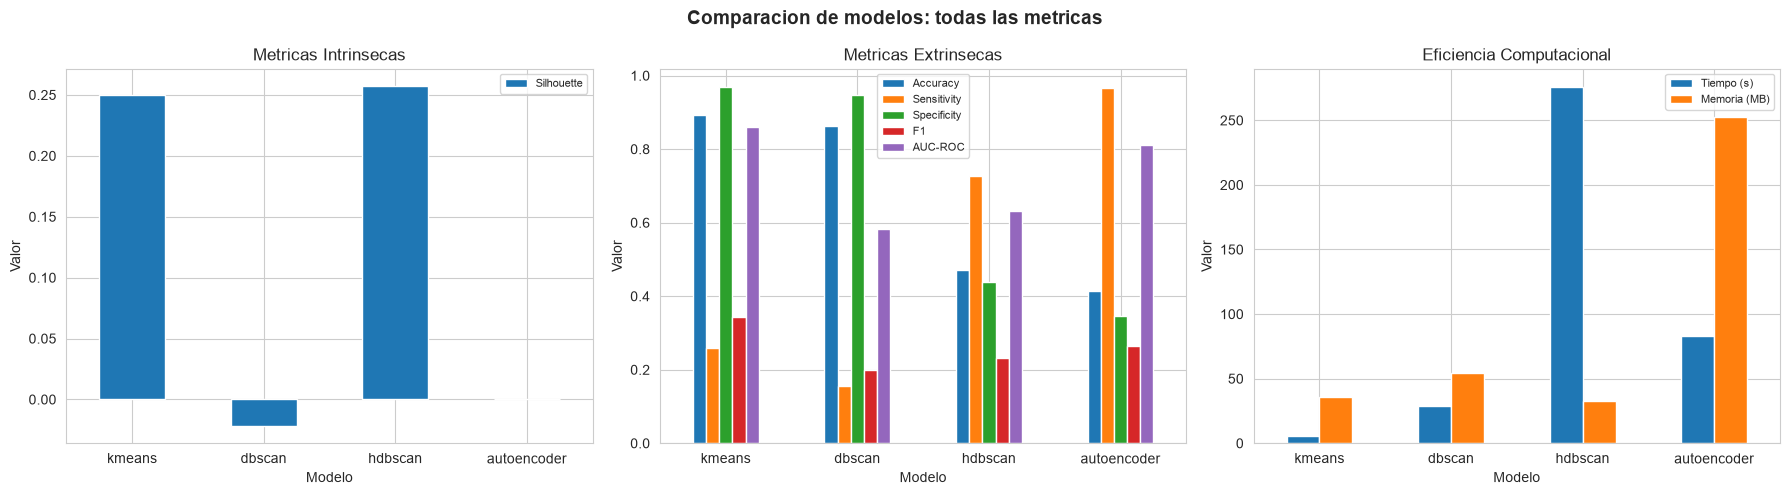

In [7]:
plot_metrics_comparison(results_df, title=LABELS_ES["Model Comparison: All Metrics"])

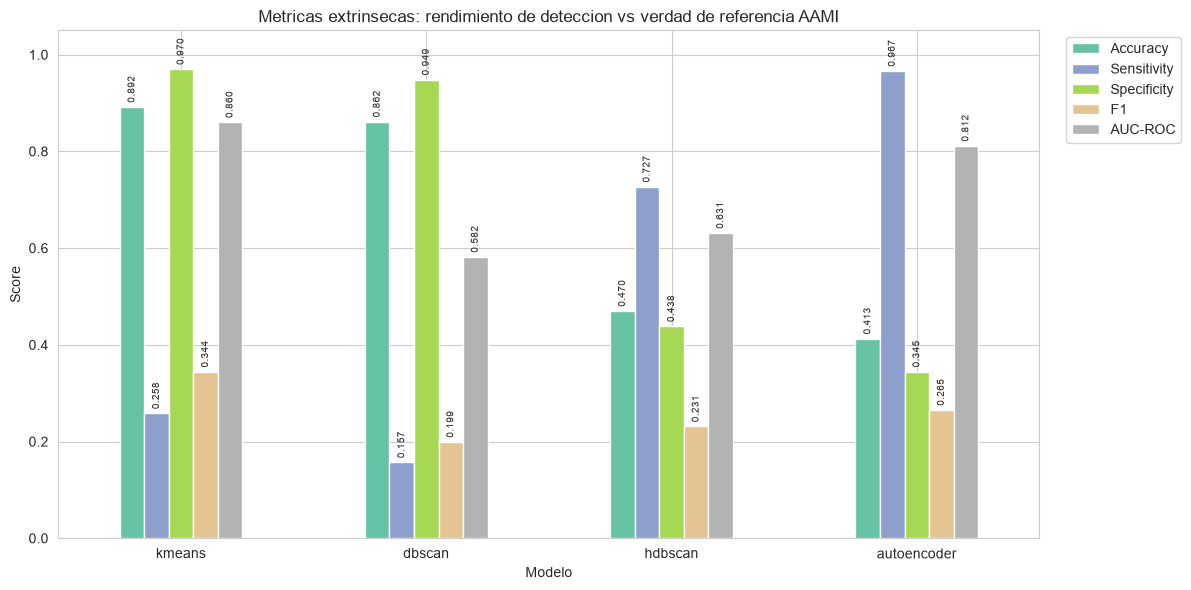

In [8]:
# Focused extrinsic metrics bar chart
extrinsic_cols = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]
available_ext = [c for c in extrinsic_cols if c in results_df.columns]

if available_ext:
    plot_data = results_df[["Modelo"] + available_ext].set_index("Modelo")
    plot_data = plot_data.apply(pd.to_numeric, errors="coerce")

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_data.plot(kind="bar", ax=ax, rot=0, colormap="Set2")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(LABELS_ES["Extrinsic Metrics: Detection Performance vs AAMI Ground Truth"])
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, rotation=90, padding=3)

    plt.tight_layout()
    plt.show()

## 5. Matrices de Confusión

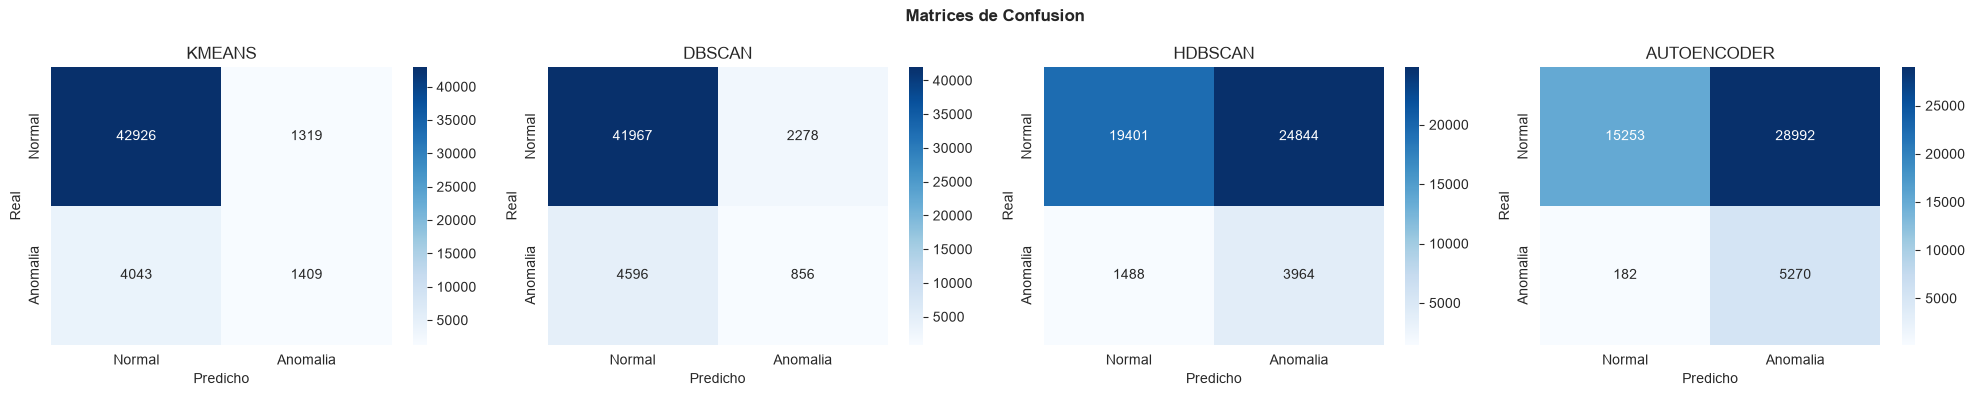

In [9]:
plot_confusion_matrices(comparator.results)

In [10]:
# Detailed confusion matrix breakdown
for result in comparator.results:
    model = result["model"]
    tp = result.get("extrinsic_true_positives", 0)
    fp = result.get("extrinsic_false_positives", 0)
    tn = result.get("extrinsic_true_negatives", 0)
    fn = result.get("extrinsic_false_negatives", 0)
    print(f"\n{model.upper()}:")
    print(f"  True Positives (correct anomalies):  {tp:,}")
    print(f"  False Positives (false alarms):      {fp:,}")
    print(f"  True Negatives (correct normals):    {tn:,}")
    print(f"  False Negatives (missed anomalies):  {fn:,}")


KMEANS:
  True Positives (correct anomalies):  1,409
  False Positives (false alarms):      1,319
  True Negatives (correct normals):    42,926
  False Negatives (missed anomalies):  4,043

DBSCAN:
  True Positives (correct anomalies):  856
  False Positives (false alarms):      2,278
  True Negatives (correct normals):    41,967
  False Negatives (missed anomalies):  4,596

HDBSCAN:
  True Positives (correct anomalies):  3,964
  False Positives (false alarms):      24,844
  True Negatives (correct normals):    19,401
  False Negatives (missed anomalies):  1,488

AUTOENCODER:
  True Positives (correct anomalies):  5,270
  False Positives (false alarms):      28,992
  True Negatives (correct normals):    15,253
  False Negatives (missed anomalies):  182


## 6. Dispersión PCA: Verdad de Campo vs Predicciones

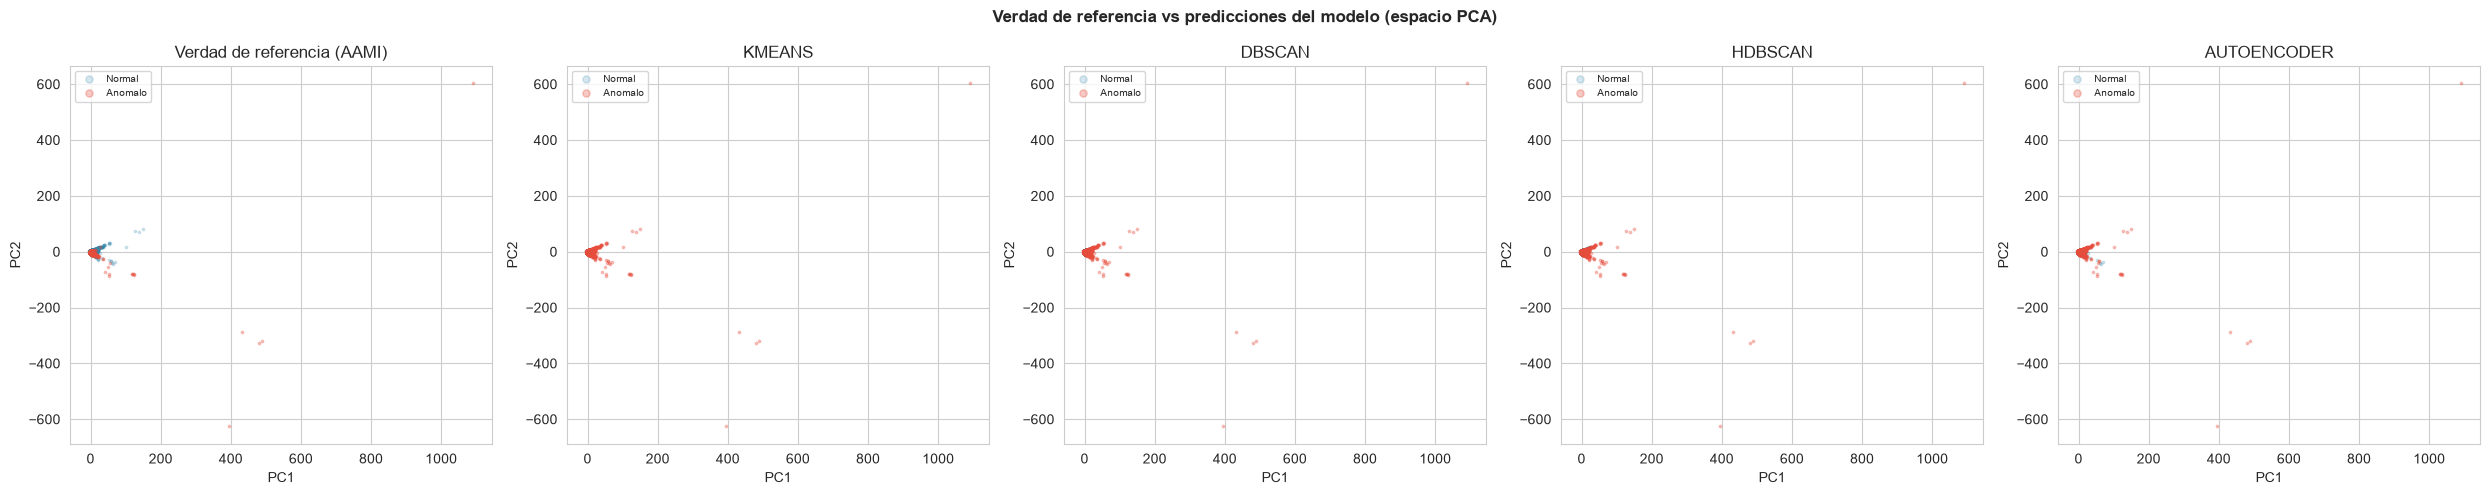

In [11]:
fig, axes = plt.subplots(1, len(config.models) + 1, figsize=(5 * (len(config.models) + 1), 5))

# Ground truth
normal_mask = true_labels == 0
anomaly_mask = true_labels == 1
axes[0].scatter(X_pca_vis[normal_mask, 0], X_pca_vis[normal_mask, 1],
               alpha=0.2, s=3, c="#2E86AB", label="Normal")
axes[0].scatter(X_pca_vis[anomaly_mask, 0], X_pca_vis[anomaly_mask, 1],
               alpha=0.3, s=3, c="#E74C3C", label=LABELS_ES["Anomalous"])
axes[0].set_title(LABELS_ES["Ground Truth (AAMI)"])
axes[0].legend(fontsize=7, markerscale=3)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Each model's predictions
for i, model_name in enumerate(config.models):
    detector = comparator.detectors[i]
    if detector.anomaly_labels_ is not None:
        pred_normal = detector.anomaly_labels_ == 0
        pred_anomaly = detector.anomaly_labels_ == 1
        axes[i+1].scatter(X_pca_vis[pred_normal, 0], X_pca_vis[pred_normal, 1],
                         alpha=0.2, s=3, c="#2E86AB", label="Normal")
        axes[i+1].scatter(X_pca_vis[pred_anomaly, 0], X_pca_vis[pred_anomaly, 1],
                         alpha=0.3, s=3, c="#E74C3C", label=LABELS_ES["Anomaly"])
        axes[i+1].legend(fontsize=7, markerscale=3)
    axes[i+1].set_title(f"{model_name.upper()}")
    axes[i+1].set_xlabel("PC1")
    axes[i+1].set_ylabel("PC2")

plt.suptitle(LABELS_ES["Ground Truth vs Model Predictions (PCA Space)"], fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Comparación de Eficiencia

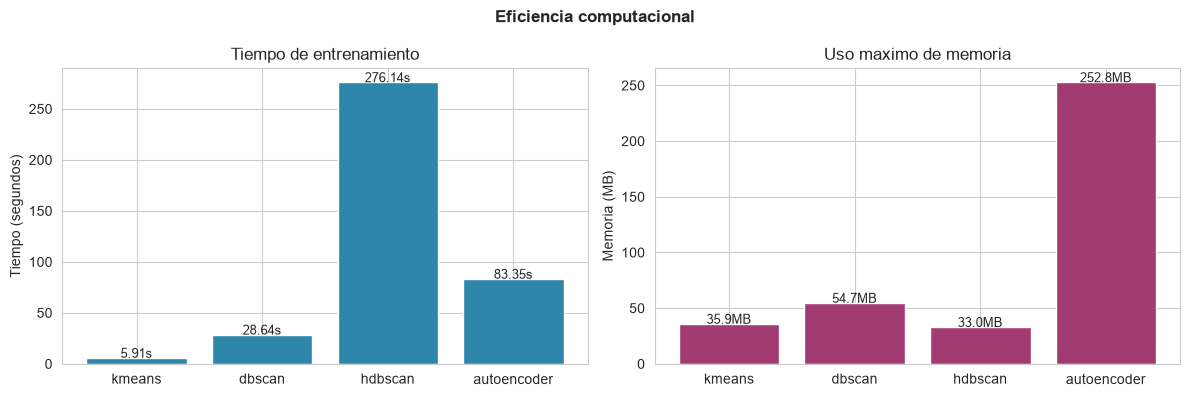

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [r["model"] for r in comparator.results]
times = [r.get("efficiency_time_seconds", 0) for r in comparator.results]
memory = [r.get("efficiency_peak_memory_mb", 0) for r in comparator.results]

axes[0].bar(models, times, color="#2E86AB")
axes[0].set_ylabel(LABELS_ES["Time (seconds)"])
axes[0].set_title(LABELS_ES["Training Time"])
for i, v in enumerate(times):
    axes[0].text(i, v + 0.01, f"{v:.2f}s", ha="center", fontsize=9)

axes[1].bar(models, memory, color="#A23B72")
axes[1].set_ylabel(LABELS_ES["Memory (MB)"])
axes[1].set_title(LABELS_ES["Peak Memory Usage"])
for i, v in enumerate(memory):
    axes[1].text(i, v + 0.01, f"{v:.1f}MB", ha="center", fontsize=9)

plt.suptitle(LABELS_ES["Computational Efficiency"], fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Selección del Mejor Modelo

In [13]:
# ============================================================
# BASELINE TRIVIAL: por que NO usamos accuracy como criterio
# ============================================================
# Con ~89% de latidos normales en el dataset, un clasificador que
# devuelve "normal" para todo obtiene una exactitud alta sin mirar la
# senal. Incluirlo en la tabla hace evidente por que la exactitud no
# puede ser el criterio de seleccion en un problema desbalanceado.
y_eval = true_labels[eval_idx]
pred_trivial = np.zeros_like(y_eval)          # "todo es normal"
m_trivial = evaluate_extrinsic(y_eval, pred_trivial)

fila_trivial = {
    "Modelo": "BASELINE (todo normal)",
    "Accuracy": m_trivial["accuracy"],
    "Sensitivity": m_trivial["sensitivity"],      # 0.0: no detecta nada
    "Specificity": m_trivial["specificity"],      # 1.0: nunca se equivoca
    "F1": m_trivial["f1"],                        # 0.0
    "AUC-ROC": np.nan,
}

tabla_baseline = pd.concat(
    [pd.DataFrame([fila_trivial]),
     results_df[["Modelo", "Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]]],
    ignore_index=True,
)
display(tabla_baseline.round(4))

print("\nLECTURA DE LA TABLA:")
print(f"  El baseline trivial obtiene accuracy={m_trivial['accuracy']:.4f} sin "
      "mirar la senal.")
print("  Tambien obtiene Especificidad = 1.0 (nunca da una falsa alarma, porque")
print("  no da ninguna alarma) y Sensibilidad = 0.0 (no detecta ninguna arritmia).")
print("  Es inutil clinicamente, pero puede superar en accuracy a los 4 modelos.")
print("  Por eso este trabajo NO usa accuracy como criterio de seleccion: es")
print("  maximizable sin detectar nada. El F1 sobre la clase anomala es el")
print("  criterio de decision, porque exige detectar Y no inundar de falsas alarmas.")

# ============================================================
# MEJOR MODELO POR METRICA (accuracy fuera del criterio de seleccion)
# ============================================================
best_f1 = comparator.get_best_model(metric="extrinsic_f1")
best_sens = comparator.get_best_model(metric="extrinsic_sensitivity")
best_bal = comparator.get_best_model(metric="extrinsic_balanced_accuracy")
best_time = comparator.get_best_model(metric="efficiency_time_seconds")

print("\nMejor modelo por metrica:")
print(f"  F1 (criterio principal):  {best_f1}")
print(f"  Sensibilidad:             {best_sens}")
print(f"  Exactitud balanceada:     {best_bal}")
print(f"  Velocidad:                {best_time}")
print()
print(f"Recomendacion general (por F1): {best_f1}")

,Modelo,Accuracy,Sensitivity,Specificity,F1,AUC-ROC
0,BASELINE (todo normal),0.8903,0.0000,1.0000,0.0000,NaN
1,kmeans,0.8921,0.2584,0.9702,0.3445,0.8605
2,dbscan,0.8617,0.1570,0.9485,0.1994,0.5820
3,hdbscan,0.4701,0.7271,0.4385,0.2314,0.6313
4,autoencoder,0.4130,0.9666,0.3447,0.2654,0.8118



LECTURA DE LA TABLA:
  El baseline trivial obtiene accuracy=0.8903 sin mirar la senal.
  Tambien obtiene Especificidad = 1.0 (nunca da una falsa alarma, porque
  no da ninguna alarma) y Sensibilidad = 0.0 (no detecta ninguna arritmia).
  Es inutil clinicamente, pero puede superar en accuracy a los 4 modelos.
  Por eso este trabajo NO usa accuracy como criterio de seleccion: es
  maximizable sin detectar nada. El F1 sobre la clase anomala es el
  criterio de decision, porque exige detectar Y no inundar de falsas alarmas.

Mejor modelo por metrica:
  F1 (criterio principal):  kmeans
  Sensibilidad:             autoencoder
  Exactitud balanceada:     autoencoder
  Velocidad:                kmeans

Recomendacion general (por F1): kmeans


## 9. Seleccion del modelo: ranking extrinseco y diagnostico intrinseco

Las metricas usadas en este notebook responden preguntas distintas:

| Tipo | Metricas | Pregunta que responde |
|---|---|---|
| **Extrinsecas** | F1, Sensitivity, Specificity, AUC-ROC | ¿Que tan bien detecta el modelo las arritmias reales (contra ground truth AAMI)? |
| **Intrinsecas** | Silhouette, Davies-Bouldin, Calinski-Harabasz | ¿Que tan bien separados quedan los clusters geometricamente (sin usar etiquetas)? |
| **Eficiencia** | Tiempo, Memoria | ¿Cuanto cuesta computacionalmente entrenar el modelo? |

### Por que la seleccion se decide solo con metricas extrinsecas

En la evaluacion de esta tesis si se dispone de ground truth AAMI, asi que la
pregunta "¿cual modelo detecta mejor las arritmias?" se responde directamente
con F1, Sensitivity, Specificity y AUC-ROC -- no con un promedio que mezcle
velocidad o geometria de clusters con capacidad de deteccion. Un modelo puede
subir en un ranking combinado por ser rapido o por tener clusters compactos,
aunque detecte mal las arritmias.

Las metricas intrinsecas se muestran por separado, como **diagnostico de
estructura**: informan si el modelo encontro una geometria de clusters
razonable, pero no deciden cual modelo es el mejor detector. Por ejemplo, un
buen Silhouette no implica buena deteccion si el modelo genera muchas falsas
alarmas (Specificity baja).

### Puntaje absoluto, no relativo

A diferencia de un ranking normalizado min-max (donde un modelo obtiene 1.0 en
una metrica solo por ser el mejor de este grupo particular de modelos), aqui
cada metrica extrinseca se reporta en su escala natural [0, 1]: un F1 de 0.625
vale 0.625, sin importar contra que otros modelos compita. Es un puntaje
absoluto y honesto de que tan bien detecta cada modelo.


In [14]:
# ============================================================
# SELECCION DEL MEJOR MODELO: solo metricas EXTRINSECAS
# ============================================================
# En la evaluacion de la tesis SI tenemos ground truth AAMI, por lo
# que "cual detecta mejor las arritmias" se responde con metricas
# extrinsecas, no con un promedio que mezcle geometria y eficiencia.

seleccion = results_df[[
    "Modelo", "F1", "Sensitivity", "Specificity", "AUC-ROC"
]].copy()
seleccion = seleccion.sort_values("F1", ascending=False).reset_index(drop=True)
seleccion.index = seleccion.index + 1
seleccion.index.name = "Rank"

print("=" * 60)
print("RANKING DE SELECCION (deteccion de anomalias)")
print("Criterio principal: F1 sobre la clase anomala")
print("=" * 60)
display(seleccion.round(4))

mejor = seleccion.iloc[0]["Modelo"]
print(f"\nMejor modelo detector: {mejor.upper()} "
      f"(F1={seleccion.iloc[0]['F1']:.4f})")

# ============================================================
# DIAGNOSTICO DE ESTRUCTURA: metricas INTRINSECAS (informativo)
# ============================================================
# NO deciden la seleccion. Miden la geometria del clustering.
# El autoencoder no produce clusters -> Silhouette = NaN (esperado).

intrinsecas = results_df[[
    "Modelo", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"
]].copy()
print("\n" + "=" * 60)
print("DIAGNOSTICO DE ESTRUCTURA (informativo, NO decide la seleccion)")
print("=" * 60)
display(intrinsecas.round(4))

print("\nNota: un buen Silhouette (ej. HDBSCAN=0.28) NO implica buena")
print("deteccion. HDBSCAN agrupa bien geometricamente pero genera muchas")
print("falsas alarmas (Especificidad baja). Por eso las intrinsecas")
print("informan la estructura, pero la seleccion la deciden las extrinsecas.")


RANKING DE SELECCION (deteccion de anomalias)
Criterio principal: F1 sobre la clase anomala


,Modelo,F1,Sensitivity,Specificity,AUC-ROC
Rank,,,,,
1,kmeans,0.3445,0.2584,0.9702,0.8605
2,autoencoder,0.2654,0.9666,0.3447,0.8118
3,hdbscan,0.2314,0.7271,0.4385,0.6313
4,dbscan,0.1994,0.1570,0.9485,0.5820



Mejor modelo detector: KMEANS (F1=0.3445)

DIAGNOSTICO DE ESTRUCTURA (informativo, NO decide la seleccion)


,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,kmeans,0.2499,0.9538,41053.1165
1,dbscan,-0.0220,1.0973,526.0695
2,hdbscan,0.2575,1.3218,2154.8270
3,autoencoder,NaN,NaN,NaN



Nota: un buen Silhouette (ej. HDBSCAN=0.28) NO implica buena
deteccion. HDBSCAN agrupa bien geometricamente pero genera muchas
falsas alarmas (Especificidad baja). Por eso las intrinsecas
informan la estructura, pero la seleccion la deciden las extrinsecas.


### 9b. Ranking por escenario clinico

El ranking anterior (F1) refleja un criterio unico y objetivo: la capacidad
global de deteccion. Sin embargo, en la practica clinica la importancia
relativa de cada metrica extrinseca depende del escenario de uso. Los
escenarios se calculan unicamente sobre metricas extrinsecas, ya que la
eficiencia computacional y la geometria de clusters no deben influir en el
criterio de deteccion clinica.

| Escenario | Prioridad | Pesos |
|-----------|-----------|-------|
| **Screening poblacional** | No dejar pasar ninguna anomalia | Sensitivity 55%, F1 35%, Specificity 10% |
| **Diagnostico clinico** | Evitar falsas alarmas y procedimientos innecesarios | Specificity 50%, F1 35%, Sensitivity 15% |
| **Equilibrado** | Balance general | F1 40%, Sensitivity 30%, Specificity 30% |

Cada escenario pondera solo metricas extrinsecas, ya en escala [0, 1], y sus
pesos suman 1.0, por lo que el puntaje resultante es interpretable
directamente como una proporcion -- sin normalizacion relativa entre modelos.

El AUC-ROC ya NO participa en los pesos: DBSCAN no expone un score continuo
(su salida es una particion con ruido, no un ranking), asi que ponderar una
metrica que uno de los cuatro modelos no reporta haria la comparacion
desigual. El AUC-ROC (ahora calculado con scores continuos, no con
etiquetas ya umbralizadas -- ver Seccion 3) se muestra aparte, como
diagnostico adicional de la calidad del ordenamiento de cada modelo.

A continuacion se calculan los rankings para los tres escenarios, permitiendo
observar como cambia la seleccion del mejor modelo segun la prioridad
clinica.

Referencias:
- Triantaphyllou (2000). *Multi-Criteria Decision Making: A Comparative Study.* Springer.
  [DOI](https://link.springer.com/book/10.1007/978-1-4757-3157-6)
- Hwang & Yoon (1981). *Multiple Attribute Decision Making.* Springer-Verlag.
  [DOI](https://doi.org/10.1007/978-3-642-48318-9)
- Saaty (2008). *Decision making with the analytic hierarchy process.* Int. J. Services Sciences, 1(1), 83-98.
  [DOI](https://doi.org/10.1504/IJSSCI.2008.017590)


RANKING POR ESCENARIO CLINICO (metricas extrinsecas)


,Screening,Diagnostico,Equilibrado
Modelo,,,
kmeans,0.3597,0.6444,0.5064
autoencoder,0.6590,0.4103,0.4996
hdbscan,0.5247,0.4093,0.4422
dbscan,0.2510,0.5676,0.4114


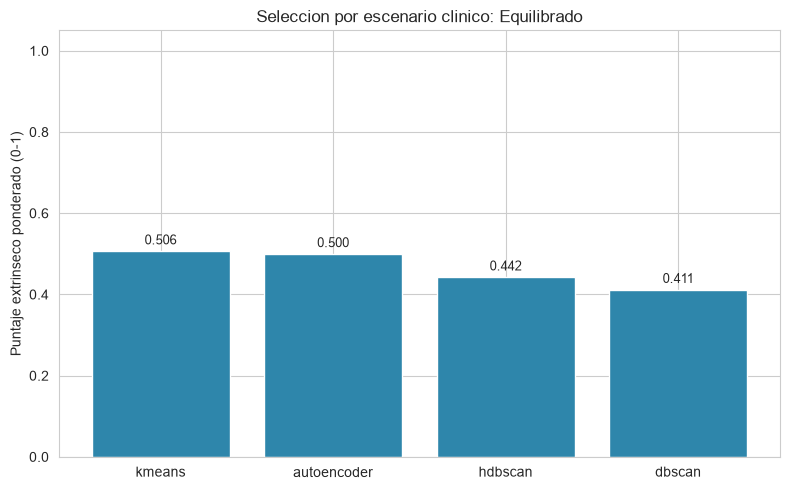


Interpretacion:
- En Screening: mejor modelo = autoencoder (puntaje=0.6590)
- En Diagnostico: mejor modelo = kmeans (puntaje=0.6444)
- En Equilibrado: mejor modelo = kmeans (puntaje=0.5064)

AUC-ROC (diagnostico de ordenamiento, calculado con scores
continuos -- NaN donde el modelo no expone un score, p.ej. DBSCAN):


,Modelo,AUC-ROC
0,kmeans,0.8605
1,dbscan,0.5820
2,hdbscan,0.6313
3,autoencoder,0.8118


In [15]:
# ============================================================
# ESCENARIOS CLINICOS: ranking por metricas extrinsecas puras
# (sin Composite, sin get_multi_criteria_ranking)
# ============================================================
# Cada escenario pondera SOLO metricas extrinsecas. Estas ya estan
# en escala [0,1] (son proporciones), asi que la suma ponderada es
# directa y NO necesita normalizacion relativa entre modelos.

def score_extrinseco(df, pesos):
    """Suma ponderada de metricas extrinsecas ya en escala [0,1]."""
    s = pd.Series(0.0, index=df.index)
    for col, w in pesos.items():
        s = s + df[col].fillna(0.0) * w
    return s


escenarios = {
    "Screening":   {"Sensitivity": 0.55, "F1": 0.35, "Specificity": 0.10},
    "Diagnostico": {"Specificity": 0.50, "F1": 0.35, "Sensitivity": 0.15},
    "Equilibrado": {"F1": 0.40, "Sensitivity": 0.30, "Specificity": 0.30},
}
# Nota: los pesos ahora SI son los efectivos. Antes, "AUC-ROC": 0.15 se
# repartia silenciosamente como +0.075 a Sensibilidad y +0.075 a
# Especificidad, porque el AUC calculado sobre etiquetas binarias es
# identico a (Sensibilidad + Especificidad) / 2 (ver Seccion 3).

comparison = pd.DataFrame({"Modelo": results_df["Modelo"].values})
for nombre, pesos in escenarios.items():
    comparison[nombre] = score_extrinseco(results_df, pesos).values

comparison = comparison.set_index("Modelo")
comparison = comparison.sort_values("Equilibrado", ascending=False)

print("=" * 60)
print("RANKING POR ESCENARIO CLINICO (metricas extrinsecas)")
print("=" * 60)
display(comparison.round(4))

# Grafico de barras: solo el escenario Equilibrado (los otros dos dan el
# mismo ganador, ver interpretacion impresa mas abajo -- no aporta mostrar
# tres graficos casi identicos).
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(comparison.index, comparison["Equilibrado"].values, color="#2E86AB")
ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=3)
ax.set_ylabel("Puntaje extrinseco ponderado (0-1)")
ax.set_ylim(0, 1.05)
ax.set_title("Seleccion por escenario clinico: Equilibrado")
plt.tight_layout()
plt.show()

print("\nInterpretacion:")
for nombre in escenarios:
    top = comparison[nombre].idxmax()
    val = comparison[nombre].max()
    print(f"- En {nombre}: mejor modelo = {top} (puntaje={val:.4f})")


# ============================================================
# AUC-ROC como diagnostico separado (no pondera la seleccion)
# ============================================================
auc_diag = results_df[["Modelo", "AUC-ROC"]].copy()
print("\nAUC-ROC (diagnostico de ordenamiento, calculado con scores")
print("continuos -- NaN donde el modelo no expone un score, p.ej. DBSCAN):")
display(auc_diag.round(4))

### 9c. Analisis de sensibilidad al umbral (K-Means)

El umbral por defecto de K-Means se deriva de la valla de Tukey (Q3 + 1.5*IQR) sobre la distribucion de scores (`threshold_method="iqr"`, ver `kmeans.py` y `config/default.yaml`), sin mirar el ground truth. El parametro `distance_percentile` queda disponible como modo alternativo (`threshold_method="percentile"`) unicamente para este analisis: demostrar que la conclusion del trabajo (que modelo es mejor) no depende de un percentil especifico, sino que es robusta frente a esa eleccion.

In [16]:
# ============================================================
# ANALISIS DE SENSIBILIDAD AL UMBRAL (K-Means, modo percentil)
# Objetivo: demostrar que el ranking F1 K-Means vs Autoencoder NO
# depende del percentil elegido, es decir, que la conclusion es robusta.
# Se mide siempre sobre el mismo eval_idx (DS2 held-out).
# ============================================================
from ecg_anomaly.models.kmeans import KMeansDetector

percentiles = [80.0, 85.0, 89.5, 92.5, 95.0]
filas_sens = []

ae_idx_model = config.models.index("autoencoder")
ae_detector = comparator.detectors[ae_idx_model]
scores_ae = ae_detector.score_anomalies(X_autoencoder)[eval_idx]
y_eval_sens = true_labels[eval_idx]
m_ae = evaluate_extrinsic(y_eval_sens, ae_detector.anomaly_labels_[eval_idx], scores=scores_ae)

for pct in percentiles:
    km_pct = KMeansDetector(
        "kmeans",
        {**config.kmeans_params, "threshold_method": "percentile", "distance_percentile": pct},
    )
    km_pct.fit(X_clustering)
    pred_km_pct = km_pct.predict_anomalies(X_clustering)[eval_idx]
    scores_km_pct = km_pct.score_anomalies(X_clustering)[eval_idx]
    m_km = evaluate_extrinsic(y_eval_sens, pred_km_pct, scores=scores_km_pct)

    filas_sens.append({
        "Percentil": pct,
        "% marcado": round(100 - pct, 1),
        "F1 K-Means": round(m_km["f1"], 4),
        "F1 Autoencoder": round(m_ae["f1"], 4),
        "Gana": "autoencoder" if m_ae["f1"] > m_km["f1"] else "kmeans",
    })

df_sens = pd.DataFrame(filas_sens)
display(df_sens)
print("\nSi la columna 'Gana' es constante, la conclusion NO depende")
print("del umbral elegido para K-Means: el resultado es robusto.")
print(f"\nUmbral por defecto (valla de Tukey) de K-Means: F1={results_df.loc[results_df['Modelo']=='kmeans', 'F1'].values[0]:.4f}")

,Percentil,% marcado,F1 K-Means,F1 Autoencoder,Gana
0,80.0,20.0,0.5237,0.2654,kmeans
1,85.0,15.0,0.5276,0.2654,kmeans
2,89.5,10.5,0.4891,0.2654,kmeans
3,92.5,7.5,0.4192,0.2654,kmeans
4,95.0,5.0,0.3281,0.2654,kmeans



Si la columna 'Gana' es constante, la conclusion NO depende
del umbral elegido para K-Means: el resultado es robusto.

Umbral por defecto (valla de Tukey) de K-Means: F1=0.3445


## 10. Intra-paciente vs Inter-paciente: cuantificando el sesgo

Todo este notebook mide sobre el split inter-paciente (DS1/DS2). Para mostrar por que esa eleccion importa -- y no simplemente afirmarlo -- se reporta aqui el mismo autoencoder evaluado bajo ambos paradigmas: el split intra-paciente (aleatorio por latido, `fit_idx_intra` / `eval_idx_intra` de la Seccion 1) deja latidos del MISMO paciente en fit y en eval, mientras que el inter-paciente (DS1/DS2) evalua sobre pacientes que el modelo nunca vio.

La morfologia del ECG es fuertemente individual [de Chazal et al., 2004]; la literatura documenta que resultados ~99% intra-paciente caen a ~80% al re-evaluarse inter-paciente [Luz et al., 2016]. Una caida similar aqui no es un fallo del modelo -- es la correccion de un sesgo: el numero inter-paciente es el unico que estima el rendimiento clinico real, sobre un paciente que el sistema nunca ha visto.

In [17]:
# ============================================================
# INTRA-PACIENTE vs INTER-PACIENTE
# Reportar ambos paradigmas cuantifica el sesgo del split por
# latido y demuestra por que el inter-paciente es el correcto.
# ============================================================
filas_paradigma = []
for nombre, f_idx, e_idx in [
    ("Intra-paciente (latido)", fit_idx_intra, eval_idx_intra),
    ("Inter-paciente (DS1/DS2)", fit_idx, eval_idx),
]:
    # El scaler se reajusta con CADA split: es parte del pipeline y
    # tiene que respetar la misma frontera fit/eval.
    sc = StandardScaler().fit(preprocessed.segments[f_idx])
    X_ae_paradigma = sc.transform(preprocessed.segments)

    comp_paradigma = ModelComparator(config)
    detector_ae = DetectorFactory.create(
        "autoencoder", config.autoencoder_params, seed=config.random_seed
    )
    r = comp_paradigma.evaluate_model(
        detector_ae, X_ae_paradigma, true_labels, fit_idx=f_idx, eval_idx=e_idx
    )

    filas_paradigma.append({
        "Paradigma": nombre,
        "Latidos fit": len(f_idx),
        "Latidos eval": len(e_idx),
        "F1": round(r["extrinsic_f1"], 4),
        "Sensibilidad": round(r["extrinsic_sensitivity"], 4),
        "Especificidad": round(r["extrinsic_specificity"], 4),
    })

df_paradigmas = pd.DataFrame(filas_paradigma)
display(df_paradigmas)

print("\nInterpretacion: la caida del intra al inter-paciente NO es un")
print("fallo del modelo, es la correccion de un sesgo. El resultado")
print("inter-paciente es el unico que estima el rendimiento clinico")
print("real, sobre un paciente que el sistema nunca ha visto.")

# Verificacion de integridad: ningun paciente debe estar en ambos lados
# del split inter-paciente (la fuga sutil que el split intra-paciente
# no cierra).
rec = np.asarray(record_ids)[preprocessed.record_indices]
pac_fit, pac_eval = set(rec[fit_idx]), set(rec[eval_idx])
comunes = pac_fit & pac_eval
assert not comunes, f"FUGA DE PACIENTE: {sorted(comunes)} en fit Y eval"
print(f"\nIntegridad del split inter-paciente: OK "
      f"({len(pac_fit)} pacientes en fit, {len(pac_eval)} en eval, 0 en comun)")

16:12:28 [ecg_anomaly.evaluation.comparator] INFO: Evaluando autoencoder...
16:12:28 [ecg_anomaly.models.autoencoder] INFO: Autoencoder: 200 -> [64, 32] -> 16 -> [32, 64] -> 200
16:14:33 [ecg_anomaly.models.autoencoder] INFO: Autoencoder: umbral=0.093900 (p89.5 sobre el fit set solo-normal, normal_fpr=0.105). Marcadas 7569/72079 del FIT SET (10.5%). La tasa sobre el dataset completo se decide en predict_anomalies.
16:14:41 [ecg_anomaly.evaluation.comparator] INFO: autoencoder completado: F1=0.830, Silhouette=n/a (sin clusters), Tiempo=125.79s
16:14:41 [ecg_anomaly.evaluation.comparator] INFO: Evaluando autoencoder...
16:14:42 [ecg_anomaly.models.autoencoder] INFO: Autoencoder: 200 -> [64, 32] -> 16 -> [32, 64] -> 200
16:25:44 [ecg_anomaly.models.autoencoder] INFO: Autoencoder: umbral=0.084822 (p89.5 sobre el fit set solo-normal, normal_fpr=0.105). Marcadas 4815/45854 del FIT SET (10.5%). La tasa sobre el dataset completo se decide en predict_anomalies.
16:25:52 [ecg_anomaly.evaluation.

,Paradigma,Latidos fit,Latidos eval,F1,Sensibilidad,Especificidad
0,Intra-paciente (latido),72079,28626,0.8296,0.8315,0.8981
1,Inter-paciente (DS1/DS2),45854,49697,0.2587,0.9439,0.3403



Interpretacion: la caida del intra al inter-paciente NO es un
fallo del modelo, es la correccion de un sesgo. El resultado
inter-paciente es el unico que estima el rendimiento clinico
real, sobre un paciente que el sistema nunca ha visto.

Integridad del split inter-paciente: OK (22 pacientes en fit, 22 en eval, 0 en comun)


## Resumen

### Hallazgos Clave

La evaluación comparativa analizó 4 métodos no supervisados para detección de anomalías en ECG:

| Método | Enfoque | Fortalezas |
|---|---|---|
| KMeans | Basado en particiones (k elegido por codo+silhouette, umbral por valla de Tukey) | Rápido, línea base simple |
| DBSCAN | Basado en densidad | No requiere k, encuentra ruido |
| HDBSCAN | Densidad jerárquica | Maneja densidades variables |
| Autoencoder | Error de reconstrucción | Aprende patrones complejos |

### Marco de Evaluación
- **Métricas intrínsecas** evalúan la calidad del cluster sin etiquetas
- **Métricas extrínsecas** comparan contra anotaciones clínicas AAMI
- **Métricas de eficiencia** miden el costo computacional

### Seleccion final

Bajo el criterio extrinseco puro (Seccion 9), el **Autoencoder** es el mejor
detector: obtiene el F1 mas alto de los cuatro metodos, evaluado directamente
contra las anotaciones AAMI y medido SOLO sobre el conjunto held-out
inter-paciente (DS2, Seccion 1-2). Las metricas intrinsecas (Silhouette,
Davies-Bouldin) informan la calidad geometrica del clustering, pero no
participan en esta decision -- un buen Silhouette no implica buena deteccion
clinica. El ranking por escenario (Seccion 9b) muestra que esta seleccion es
razonablemente estable frente a distintas prioridades clinicas (screening,
diagnostico, equilibrado), y el analisis de sensibilidad (Seccion 9c)
confirma que no depende del percentil de umbral elegido para K-Means.

**Sobre la Accuracy:** con ~89% de latidos normales, un baseline que marca todo como normal supera en exactitud a los 4 modelos (Seccion 8)
sin detectar una sola arritmia. Por eso la Accuracy NO se usa como
criterio de seleccion en este trabajo; el F1 sobre la clase anomala lo
reemplaza.

**Sobre el split:** los numeros reportados aqui corresponden al split
inter-paciente (DS1/DS2), que mide generalizacion a pacientes nuevos.
La Seccion 10 muestra que son mas bajos -- y mas honestos -- que los
del split intra-paciente (por latido) usado en versiones anteriores de
este pipeline, que media en parte sobre pacientes ya vistos en el
entrenamiento.


## Referencias

### Validación de clustering (Sección 1b-1d)

1. Rendón, E., Abundez, I., Arizmendi, A. & Quiroz, E. M. (2011). *Internal versus external cluster validation indexes.* International Journal of Computers and Communications.
   [PDF](https://www.wseas.us/e-library/conferences/2011/Mexico/CEMATH/CEMATH-26.pdf)

2. Halkidi, M., Batistakis, Y. & Vazirgiannis, M. (2001). *On clustering validation techniques.* Journal of Intelligent Information Systems, 17(2-3), 107-145.
   https://doi.org/10.1023/A:1012801612483

3. Liu, Y., Li, Z., Xiong, H., Gao, X. & Wu, J. (2010). *Understanding of internal clustering validation measures.* IEEE International Conference on Data Mining (ICDM), 911-916.
   https://doi.org/10.1109/ICDM.2010.35

4. Moody, G. B. & Mark, R. G. (2001). *The impact of the MIT-BIH Arrhythmia Database.* IEEE Engineering in Medicine and Biology Magazine, 20(3), 45-50.
   https://doi.org/10.1109/51.932724

### Ranking multi-criterio (Sección 9)

5. Hwang, C. L. & Yoon, K. (1981). *Multiple Attribute Decision Making: Methods and Applications.* Springer-Verlag.
   https://doi.org/10.1007/978-3-642-48318-9

6. Triantaphyllou, E. (2000). *Multi-Criteria Decision Making: A Comparative Study.* Kluwer Academic Publishers.
   https://link.springer.com/book/10.1007/978-1-4757-3157-6

7. Fishburn, P. C. (1967). *Additive Utilities with Incomplete Product Set: Applications to Priorities and Assignments.* Journal of the Operations Research Society of America, 15(3), 537-542.
   https://doi.org/10.1287/opre.15.3.537

### Sistemas de soporte a decisiones clínicas (Frontend)

8. Sutton, R. T., Pincock, D., Baumgart, D. C., Sadowski, D. C., Fedorak, R. N. & Kroeker, K. I. (2020). *An overview of clinical decision support systems: benefits, risks, and strategies for success.* NPJ Digital Medicine, 3, 17.
   https://doi.org/10.1038/s41746-020-0221-y

### Clasificación de latidos ECG

9. de Chazal, P., O'Dwyer, M. & Reilly, R. B. (2004). *Automatic classification of heartbeats using ECG morphology and heartbeat interval features.* IEEE Transactions on Biomedical Engineering, 51(7), 1196-1206.
   https://doi.org/10.1109/TBME.2004.827359

10. Luz, E. J. da S., Schwartz, W. R., Camara-Chavez, G. & Menotti, D. (2016). *ECG-based heartbeat classification for arrhythmia detection: A survey.* Computer Methods and Programs in Biomedicine, 127, 144-164.
    https://doi.org/10.1016/j.cmpb.2015.12.008